# JCM + slab models on a displaced-pole grid

In [1]:
from importlib import resources
from pathlib import Path

import jcm
from jcm.physics.speedy.speedy_coords import get_speedy_coords
import jax_datetime as jdt
import xarray as xr

from jem.components import JCM, SlabOceanModel, SlabSeaiceModel
from jem.components.slab.grid import generate_slab_grid_from_scrip
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools
from jem.utils.esmf_regrid import ESMFRegridder
use_ipython = 'get_ipython' in globals()

/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurations

In [2]:
# Configurations
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
simulation_name = "02-05_jcm_slabs_mixed_grid_aqua_planet"
output_dir = (Path("output") / simulation_name).resolve()
output_dir.mkdir(exist_ok=True, parents=True)
output_figure = output_dir / "animation_humidity_sst.gif"
one_second = jdt.to_timedelta(1, "second")


# Displaced-pole ocean grid, loaded from a UGRID-convention CF grid file.
# Only the slab models (ocn, seaice) use this grid -- JCM's atmosphere keeps
# its own native spectral grid; with the mapper stubbed out above, no
# regridding between the two grids is needed yet.
jem_data_dir = resources.files("jem.data")
grid_file = jem_data_dir / "DisplacedPoleGrid.SCRIP.nc"
land_fraction_file = jem_data_dir / "landsea_mask_fraction_DisplacedPoleGrid.nc"
displaced_pole_grid = generate_slab_grid_from_scrip(
    str(grid_file),
    fractional_mask=xr.open_dataset(land_fraction_file)["lsm"].to_numpy()[0].transpose(),
    threshold=0.5,
)

## Creating Flux and Scalar Exchange between Components

In [3]:
regridder = {
    "o2a": {
        "bilinear": ESMFRegridder(str(jem_data_dir / "weight_algo-bilinear_DisplacedPoleGrid_to_JCM_T31.nc")),
        "conserve": ESMFRegridder(str(jem_data_dir / "weight_algo-conserve_DisplacedPoleGrid_to_JCM_T31.nc")),
    },
    "a2o": {
        "bilinear": ESMFRegridder(str(jem_data_dir / "weight_algo-bilinear_JCM_T31_to_DisplacedPoleGrid.nc")),
        "conserve": ESMFRegridder(str(jem_data_dir / "weight_algo-conserve_JCM_T31_to_DisplacedPoleGrid.nc")),
    }
}

# Creating Flux and Scalar Exchange between Components
def mapper(coupled_carry):
    atm = coupled_carry["atm"]
    ocn = coupled_carry["ocn"]
    seaice = coupled_carry["seaice"]

    # ESMFRegridder, SlabGrid, and JCM all use (n_lon, n_lat) -- no
    # transpose needed. Flux/area quantities use conservative regridding to
    # preserve budgets; state quantities (SST) use bilinear.
    ocn["forcing"].total_heat_flux = regridder["a2o"]["conserve"](atm["derived"].total_heat_flux)
    seaice["forcing"].ice_frazil_melt_energy = ocn["derived"].ice_frazil_melt_energy
    atm["forcing"].sea_surface_temperature = regridder["o2a"]["bilinear"](ocn["state"].sea_surface_temperature)
    atm["forcing"].sice_am = regridder["o2a"]["conserve"](seaice["derived"].ice_fraction)

    return coupled_carry

## Create Components

In [4]:
atm_model = jcm.model.Model(
    coords=get_speedy_coords(),  # T31 spectral resolution with 8 vertical levels
    start_date=start_datetime,
)

atm_model = JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
)


model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            grid=displaced_pole_grid,
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
        seaice=SlabSeaiceModel(
            grid=displaced_pole_grid,
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `collections.abc.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `collections.abc.Callable[[], dict]`
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `collections.abc.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `collections.abc.Callable[[], dict]`
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_x

## Run Coupled Model

In [5]:
simulation_interval = jdt.to_timedelta(180, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "atm", "ocn", "seaice"],
    iterations = int(simulation_interval / coupling_timestep),
)

/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:126: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Boundary does not exist. Idealized initial SST will be used.


grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.


Flattened workflow:  mapper, atm, ocn, seaice
generate_trajectory_function took 0.03 seconds.


Using method: None


...

Simulation:  85%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████                    | 153/180 [00:06<00:01, 23.24it/s]

Simulation:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋             | 162/180 [00:06<00:00, 23.23it/s]

Simulation:  95%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎      | 171/180 [00:07<00:00, 23.24it/s]

Simulation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:07<00:00, 23.99it/s]

Simulation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:07<00:00, 23.38it/s]

## Output into NetCDF

In [6]:
output_dict = model.predictions_to_xarray(predictions)
output_dict_subsample = {}
subsample_skip = 5
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print(f"Output file: {str(output_file)}, with subsample_skip = {subsample_skip:d}")
    ds = ds.isel(time=slice(None, None, subsample_skip))
    ds.to_netcdf(output_file, engine="netcdf4")
    output_dict_subsample[component_name] = ds

Output file: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/02-05_jcm_slabs_mixed_grid_aqua_planet/atm.nc, with subsample_skip = 5


Output file: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/02-05_jcm_slabs_mixed_grid_aqua_planet/ocn.nc, with subsample_skip = 5
Output file: /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/02-05_jcm_slabs_mixed_grid_aqua_planet/seaice.nc, with subsample_skip = 5


## Visualization: animation of specific humidity of the surface grid

Saving animation:  /home/tienyiao/projects_local/project_jax-esm/jem_repo/jax-esm/examples/01_basic/output/02-05_jcm_slabs_mixed_grid_aqua_planet/animation_humidity_sst.gif
Plotting frame=0


Plotting frame=0


Plotting frame=1


Plotting frame=2


Plotting frame=3


...

Plotting frame=31


Plotting frame=32


Plotting frame=33


Plotting frame=34


Plotting frame=35


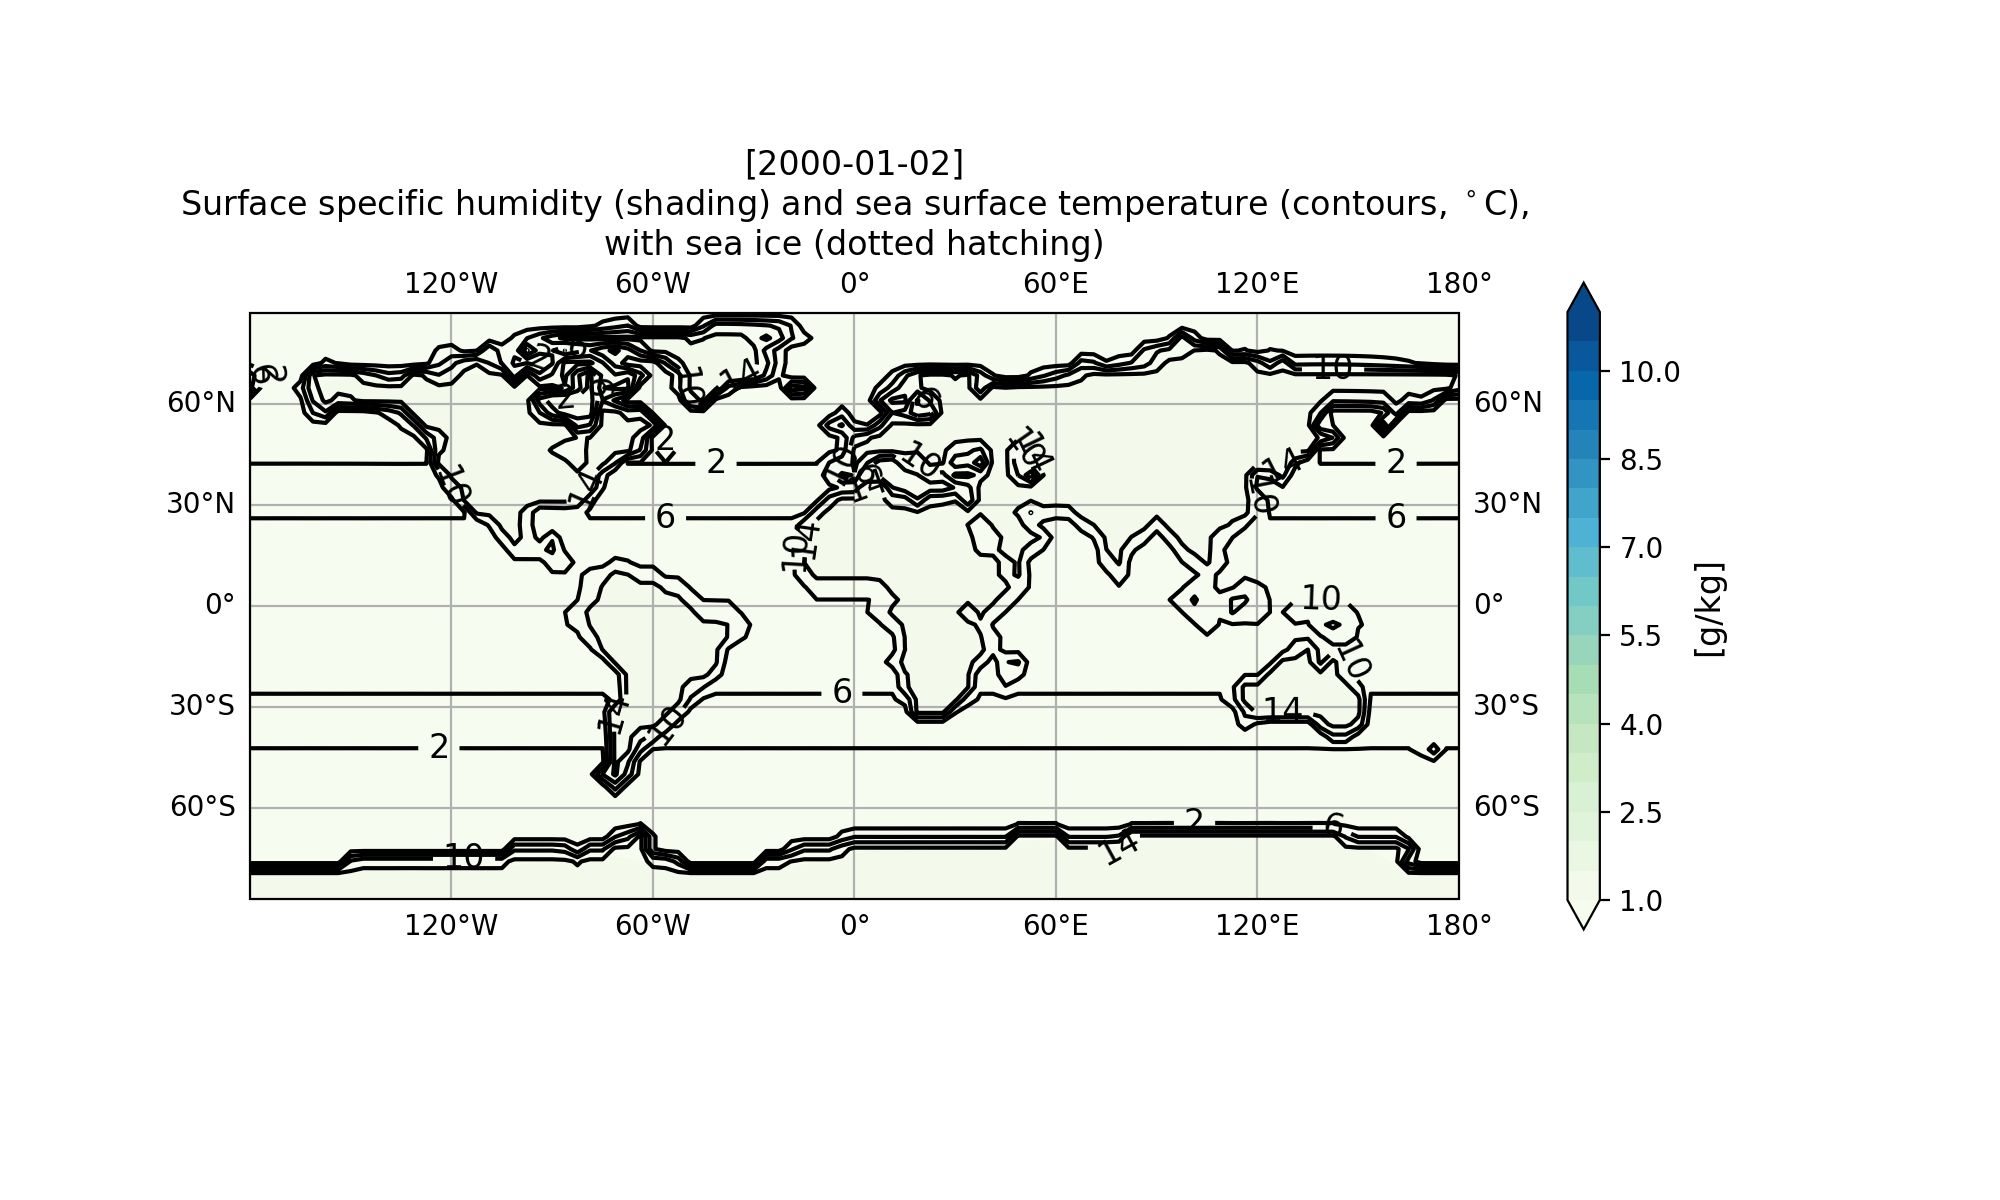

Plotting frame=0


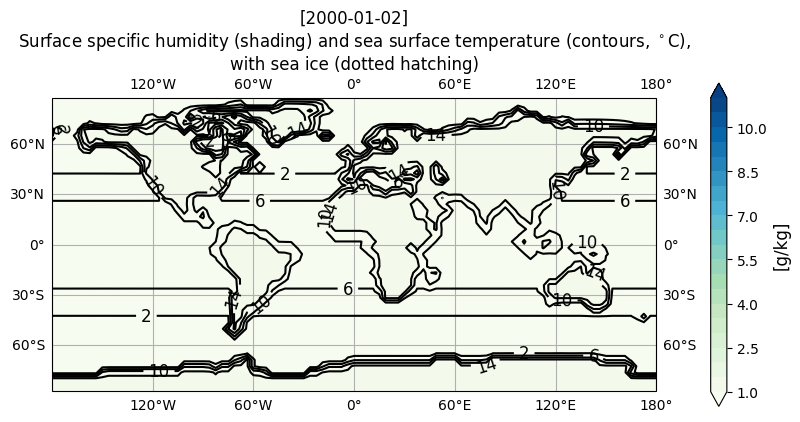

In [7]:
import matplotlib as mplt
if not use_ipython:
    mplt.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import numpy as np

output_dict_animation = {
    component_name: _ds.isel(time=slice(None, None, 1))
    for component_name, _ds in output_dict_subsample.items()
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)
cb = None
cf = None
cs = None
ch = None

def update(frame):
    print(f"Plotting frame={frame:d}")
    global cf, cb, cs, ch
    _data_q = output_dict_animation["atm"]["specific_humidity"].isel(time=frame, level=0)
    _data_sst = output_dict_animation["ocn"]["sea_surface_temperature"].isel(time=frame) - 273.15
    _data_sit = output_dict_animation["seaice"]["ice_thickness"].isel(time=frame)
    coords = _data_q.coords
    time_str = _data_q['time'].dt.strftime('%Y-%m-%d').to_numpy().item()
    lat = coords["lat"]
    lon = coords["lon"]

    o2a = lambda d: regridder["o2a"]["bilinear"](d)
    
    # Remove previous frame's artists before drawing the new ones
    cf and cf.remove()
    cs and cs.remove()
    ch and ch.remove()
    
    # Plot the humidity field for the current time step
    cyclic_data_q, cyclic_lon = add_cyclic_point(_data_q.to_numpy().transpose(), coord=lon)
    mappable = ax.contourf(
        cyclic_lon, lat,
        cyclic_data_q,
        levels=1 + np.linspace(0, 1, 21) * 10,
        transform=ccrs.PlateCarree(), 
        cmap='GnBu',
        extend="both",
    )
    
    cyclic_data_sst, cyclic_lon = add_cyclic_point(o2a(_data_sst.to_numpy()).transpose(), coord=lon)
    cs = ax.contour(
        cyclic_lon, lat,
        cyclic_data_sst,
        levels=np.arange(-2, 31, 4),
        transform=ccrs.PlateCarree(),
        colors="black",
    )
    ax.clabel(cs, fontsize=12)

    # Dot-hatch grid cells that carry any sea ice (thickness above zero)
    cyclic_data_sit, cyclic_lon = add_cyclic_point(o2a(_data_sit.to_numpy()).transpose(), coord=lon)
    ch = ax.contourf(
        cyclic_lon, lat,
        cyclic_data_sit,
        levels=[1e-6, np.inf],
        colors="none",
        hatches=["."],
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(f"[{time_str:s}]\nSurface specific humidity (shading) and sea surface temperature (contours, ${{}}^\\circ \\mathrm{{C}}$),\nwith sea ice (dotted hatching)")
    if cb is None:
        cb = plt.colorbar(ax=ax, mappable=mappable, orientation='vertical', shrink=0.7, pad=0.07)
        cb.set_label("[g/kg]", fontsize=12)
    
    return [cf,]
    
# Generate and save
ani = FuncAnimation(fig, update, frames=len(output_dict_animation["atm"].coords["time"]), interval=120, blit=False)
print("Saving animation: ", output_figure)
ani.save(output_figure, writer='pillow', dpi=200)

if use_ipython:
    from IPython.display import Image
    display(Image(output_figure))